In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pickle
import random
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


In [3]:
import pickle
with open('/content/drive/MyDrive/video_features_256.pkl', 'rb') as f:
    video_256 = pickle.load(f)

with open('/content/drive/MyDrive/audio_feat_hubert_origin.pkl', 'rb') as f:
    audio_256 = pickle.load(f)

text_256 = torch.load(
    '/content/drive/MyDrive/text_features_256(basic+earlystop).pkl',
    map_location='cpu'
)

print(audio_256.keys())
print(video_256.keys())
print(text_256.keys())

dict_keys(['audio_feat', 'labels'])
dict_keys(['features', 'labels'])
dict_keys(['features', 'labels'])


In [4]:
X_video_256=video_256['features']
X_audio_256=audio_256['audio_feat']
X_text_256=text_256['features']

y_all=text_256['labels']

In [5]:
X_video=X_video_256
X_audio=X_audio_256
X_text=X_text_256

print(X_video.shape)
print(X_audio.shape)
print(X_text.shape)

torch.Size([2199, 256])
torch.Size([2199, 256])
torch.Size([2199, 256])


In [6]:
X_video = F.normalize(X_video, dim=-1).detach()
X_audio = F.normalize(X_audio, dim=-1).detach()
X_text = F.normalize(X_text, dim=-1).detach()

In [7]:
class MultiModalDataset(Dataset):
    def __init__(self, video_features, audio_features, text_features, labels):
        self.video_features = video_features
        self.audio_features = audio_features
        self.text_features = text_features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        video = self.video_features[idx]
        audio = self.audio_features[idx]
        text = self.text_features[idx]
        label = self.labels[idx]
        return video, audio, text, label

# --- Train / Val / Test   분리 ---
idx = np.arange(len(y_all))
idx_tr, idx_temp = train_test_split(idx, test_size=0.3, random_state=42, stratify=y_all)
idx_te, idx_val = train_test_split(idx_temp, test_size=0.5, random_state=42, stratify=y_all[idx_temp])

train_set = MultiModalDataset(X_video[idx_tr], X_audio[idx_tr], X_text[idx_tr], y_all[idx_tr])
val_set   = MultiModalDataset(X_video[idx_val], X_audio[idx_val], X_text[idx_val], y_all[idx_val])
test_set  = MultiModalDataset(X_video[idx_te], X_audio[idx_te], X_text[idx_te], y_all[idx_te])

BATCH_SIZE = 16
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_set)}/ Val: {len(val_set)} / Test: {len(test_set)}")
v, a, t, lab = next(iter(train_loader))
print(f"video {tuple(v.shape)}  audio {tuple(a.shape)}  text {tuple(t.shape)}")

Train: 1539/ Val: 330 / Test: 330
video (16, 256)  audio (16, 256)  text (16, 256)


In [8]:
class catFusionModel(nn.Module):
    def __init__(self, shared_dim, num_classes=2):
        super().__init__()

        fused_dim = shared_dim * 3

        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, video, audio, text):
        v_feat = video
        a_feat = audio
        t_feat = text

        fused = torch.cat([v_feat, a_feat, t_feat], dim=1)

        x = self.classifier(fused)
        return x

In [9]:
class GraphMiddleFusionModel(nn.Module):
    # GCN 기반 멀티모달 융합
    def __init__(self, shared_dim=256, num_gnn_layers=2, num_classes=2,  adjacency=None):
        super().__init__()
        # self.audio_encoder = audio_encoder
        # self.text_encoder  = text_encoder
        # self.video_encoder = video_encoder

        # # --- 1) 차원 통일 ---
        # self.video_proj = nn.Linear(video_encoder.output_dim, shared_dim)
        # self.audio_proj = nn.Linear(audio_encoder.output_dim, shared_dim)
        # self.text_proj  = nn.Linear(text_encoder.output_dim, shared_dim)

        # --- 2) 인접 행렬 (3×3) - 행별 정규화 후 buffer 등록 ---
        if adjacency is not None:
            A = torch.tensor(adjacency, dtype=torch.float32)
        else:
            A = torch.ones(3,3)
        self.register_buffer("A", A/A.sum(dim=1, keepdim=True))

        # --- 3) 메시지 패싱 레이어 (각 layer = 학습 가능한 W) ---
        self.gnn_layers = nn.ModuleList([
            nn.Linear(shared_dim, shared_dim) for _ in range(num_gnn_layers)
        ])

        # --- 4) 분류기 ---
        self.classifier = nn.Sequential(
            nn.Linear(shared_dim* 3, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, video, audio, text):
        # 1) 모달별 인코딩
        # v = self.video_encoder(video)
        # a = self.audio_encoder(audio)
        # t = self.text_encoder(text)

        # 2) 차원 통일
        v = video #F.relu(self.video_proj(v))
        a = audio #F.relu(self.audio_proj(a))
        t = text #F.relu(self.text_proj(t))

        # 3) 노드 행렬 H: (B, 3, shared_dim)
        H = torch.stack([v,a,t], dim=1)

        # 4) 메시지 패싱 N번 — H' = ReLU(A · layer(H))
        for layer in self.gnn_layers:
            H = F.relu(self.A @ layer(H))

        # 5) 노드 표현을 펼쳐서 분류
        return self.classifier(H.flatten(1))

In [10]:
class LateFusionModel(nn.Module):
    def __init__(self, shared_dim, num_classes=2):
        super().__init__()

        self.clf_v =nn.Sequential(
            nn.Linear(shared_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
        self.clf_a = nn.Sequential(
            nn.Linear(shared_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
        self.clf_t = nn.Sequential(
            nn.Linear(shared_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

        self.fusion_weights = nn.Parameter(torch.ones(3) /3)

    def forward(self, video, audio, text):
        v_feat = video
        a_feat = audio
        t_feat = text

        score_v = self.clf_v(v_feat)
        score_a = self.clf_a(a_feat)
        score_t = self.clf_t(t_feat)

        w = torch.softmax(self.fusion_weights, dim=0)

        final_score = w[0] * score_v + w[1] *score_a + w[2] * score_t
        return final_score

In [11]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta

        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0

        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

In [120]:
def train_test_fusion(model, train_loader, val_loader, test_loader, num_epochs=10, lr=1e-3, label=""):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adagrad(model.parameters(), lr=lr)
    early_stopping = EarlyStopping(patience=5, min_delta=0.001)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "test_acc": 0}

    for epoch in range(num_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for v, a, t, yb in train_loader:
            v, a, t, yb = v.to(device), a.to(device), t.to(device), yb.to(device)
            out = model(v, a, t)
            loss = criterion(out, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * yb.size(0)
            correct    += (out.argmax(1) == yb).sum().item()
            total      += yb.size(0)
        train_loss = total_loss / total
        train_acc  = correct / total * 100

        model.eval()
        total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for v, a, t, yb in val_loader:
                v, a, t, yb = v.to(device), a.to(device), t.to(device), yb.to(device)
                out = model(v, a, t)
                loss = criterion(out, yb)
                total_loss += loss.item() * yb.size(0)
                correct += (out.argmax(1) == yb).sum().item()
                total   += yb.size(0)
        val_loss = total_loss / total
        val_acc = correct / total * 100

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"[{label}] Epoch {epoch+1:2d}  Train Loss: {train_loss:.4f} | TrainAcc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | ValAcc: {val_acc:.2f}%")

        early_stopping(val_loss)

        if early_stopping.early_stop:
          print("Early stopping")
          break

    # test
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
      for v,a,t, yb in test_loader:
        v, a, t, yb = v.to(device), a.to(device), t.to(device), yb.to(device)
        out = model(v, a, t)
        loss = criterion(out, yb)
        total_loss += loss.item() * yb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total   += yb.size(0)

    test_loss = total_loss / total
    test_acc = correct / total * 100

    history["test_acc"] = test_acc
    print(f"\n[{label}] TestLoss: {test_loss:.4f} | TestAcc: {test_acc:.2f}%")

    return history


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [121]:
# #concat
# SEED        = 42
# NUM_EPOCHS  = 20
# LR          = 1e-4
# SHARED_DIM  = 256
# run_name='concat'
# cat_model =catFusionModel(shared_dim=SHARED_DIM).to(device)
# history=train_test_fusion(cat_model, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS, lr=LR, label="cat")

In [122]:
# # late
# SEED        = 42
# NUM_EPOCHS  = 20
# LR          = 1e-4
# SHARED_DIM  = 256
# run_name='late'
# late_model =LateFusionModel(shared_dim=SHARED_DIM).to(device)
# history=train_test_fusion(late_model, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS, lr=LR, label="late")

In [216]:
SEED        = 42
NUM_EPOCHS  = 20
LR          = 2e-3
SHARED_DIM  = 256
NUM_GNN     = 1
A = [
    [1, 0, 1], # V
    [0, 1, 1], # A
    [0, 0, 1], # T
]

model =GraphMiddleFusionModel(shared_dim=SHARED_DIM, num_gnn_layers=NUM_GNN, num_classes=2, adjacency=A).to(device)
history=train_test_fusion(model, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS, lr=LR, label="GCN")

[GCN] Epoch  1  Train Loss: 0.2997 | TrainAcc: 91.68% | Val Loss: 0.3169 | ValAcc: 87.88%
[GCN] Epoch  2  Train Loss: 0.2371 | TrainAcc: 92.66% | Val Loss: 0.3019 | ValAcc: 88.48%
[GCN] Epoch  3  Train Loss: 0.2291 | TrainAcc: 92.72% | Val Loss: 0.2921 | ValAcc: 89.09%
[GCN] Epoch  4  Train Loss: 0.2191 | TrainAcc: 92.59% | Val Loss: 0.2832 | ValAcc: 88.79%
[GCN] Epoch  5  Train Loss: 0.2078 | TrainAcc: 92.79% | Val Loss: 0.2745 | ValAcc: 89.09%
[GCN] Epoch  6  Train Loss: 0.2028 | TrainAcc: 92.72% | Val Loss: 0.2689 | ValAcc: 89.09%
[GCN] Epoch  7  Train Loss: 0.1992 | TrainAcc: 92.92% | Val Loss: 0.2629 | ValAcc: 90.00%
[GCN] Epoch  8  Train Loss: 0.1882 | TrainAcc: 93.05% | Val Loss: 0.2609 | ValAcc: 90.30%
[GCN] Epoch  9  Train Loss: 0.1854 | TrainAcc: 93.11% | Val Loss: 0.2571 | ValAcc: 91.21%
[GCN] Epoch 10  Train Loss: 0.1804 | TrainAcc: 93.50% | Val Loss: 0.2566 | ValAcc: 90.91%
[GCN] Epoch 11  Train Loss: 0.1784 | TrainAcc: 93.31% | Val Loss: 0.2592 | ValAcc: 89.70%
[GCN] Epoc

In [217]:
run_name='self connect + v,a->t'

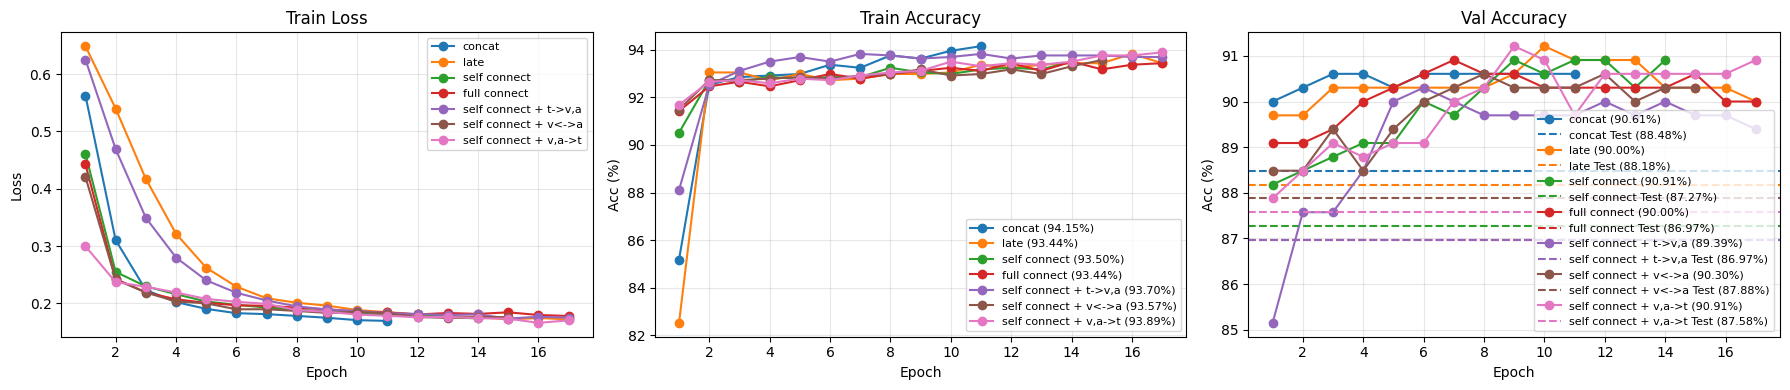


[self connect + v,a->t] 최종 Test Acc: 87.58%
누적된 실험 (7개): ['concat', 'late', 'self connect', 'full connect', 'self connect + t->v,a', 'self connect + v<->a', 'self connect + v,a->t']


In [218]:
# 같은 이름이면 덮어씀 (중복 X)

if "assign_results" not in globals():
    assign_results = {}
    fig_a, ax_a = plt.subplots(1, 3, figsize=(18, 4))
    plt.close(fig_a)
assign_results[run_name] = history
from IPython.display import display

for ax in ax_a:
    ax.clear()
for name, h in assign_results.items():
    ep = range(1, len(h["train_loss"]) + 1)
    ax_a[0].plot(ep, h["train_loss"], "-o", label=name)
    ax_a[1].plot(ep, h["train_acc"], "-o", label=f"{name} ({h['train_acc'][-1]:.2f}%)")
    line=ax_a[2].plot(ep, h["val_acc"], "-o", label=f"{name} ({h['val_acc'][-1]:.2f}%)")[0]
    ax_a[2].axhline(y=h['test_acc'], linestyle="--", color=line.get_color(), label=f"{name} Test ({h['test_acc']:.2f}%)")

for ax in ax_a:
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax_a[0].set_title("Train Loss"); ax_a[0].set_xlabel("Epoch"); ax_a[0].set_ylabel("Loss")
ax_a[1].set_title("Train Accuracy"); ax_a[1].set_xlabel("Epoch"); ax_a[1].set_ylabel("Acc (%)")
ax_a[2].set_title("Val Accuracy"); ax_a[2].set_xlabel("Epoch"); ax_a[2].set_ylabel("Acc (%)")
fig_a.tight_layout()
display(fig_a)

print(f"\n[{run_name}] 최종 Test Acc: {history['test_acc']:.2f}%")
print(f"누적된 실험 ({len(assign_results)}개): {list(assign_results.keys())}")

In [ ]:
# del assign_results